In [22]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *
# from scipy.signal import unit_impulse
import time

In [23]:
def delta(t, h, theta, t0):

    func = (theta/2) / np.sqrt(2*np.pi*h**2) * np.exp(-(t-t0)**2/(2*h**2))
    for fac in range(2, 10):
        func += (theta/2) / np.sqrt(2*np.pi*h**2) * np.exp(-(t-t0*fac)**2/(2*h**2))
    
    return func

def get_tau_r(N):
    H0, w, v, psi0, _ = get_scar_ham(N)
    amp = np.array([s.overlap(psi0) for s in v])
    ts = np.linspace(2, 15, 20000)
    f = np.abs((np.abs(amp)**2) @ np.exp(-1j * np.outer(w, ts)))**2
    return ts[np.argmax(f)]

In [24]:
N = 8
wd = 0.6366896896896898
wm = 1.0
tau_r = get_tau_r(N)
tau = 1 / 2
t_max = 50 * tau
n_t = 2000
tlist = np.linspace(0, t_max, n_t)
reals = 1
dis = 0.0

tau_r = get_tau_r(N)
print(f"tau_r = {tau_r:.4f}")

tau_r = 9.9083


In [25]:
dz = 0.0
dy = 0.0
dx = dis

h = 0.05
args = {"h": h, "theta": np.pi, "t0": tau}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1_no_z2(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, delta]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0],
                       options={"max_step": h/5, "atol": 1e-12, "rtol": 1e-10})
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
    
xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0

    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, delta]], args=args)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0],
                            options={"max_step": h/5, "atol": 1e-12, "rtol": 1e-10})
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

1 realizations in 1.9 s (1.94218 s per realization)


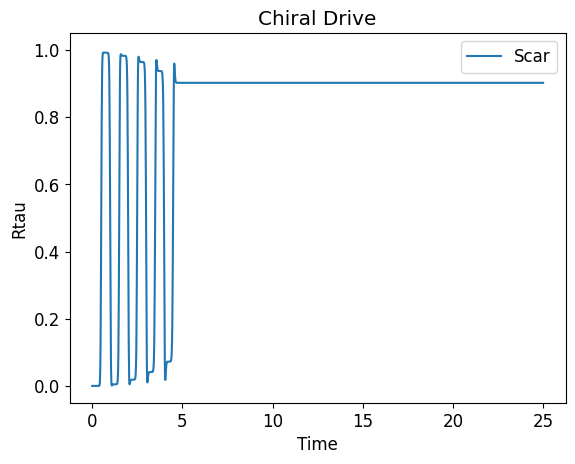

In [26]:
plt.title(f"Chiral Drive")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
# plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()